<div style="font-family: 'Segoe UI', Arial, sans-serif; 
            border-left: 5px solid #1f77b4; 
            padding: 20px; 
            background-color: #f8f9fa; 
            border-radius: 4px; 
            box-shadow: 0 1px 3px rgba(0,0,0,0.05); 
            max-width: 800px; 
            margin-bottom: 25px;">
    
<h1 style="color: #212529; margin-top: 0; margin-bottom: 5px; font-size: 26px; font-weight: 700;">
    Part II: CMS Open Data
</h1>
<br>
<p style="color: #6c757d; margin-top: 0; margin-bottom: 20px; font-size: 18px; font-weight: bold;">
    Notebook 5: Dataset Preparation
</p>

<hr style="border: 0; border-top: 1px solid #dee2e6; margin-bottom: 15px;">

<table style="border-collapse: collapse; width: 100%; font-size: 14px; line-height: 1.6;">
    <tr>
        <td style="padding: 4px 0; width: 150px; font-weight: bold; color: #495057;">Author:</td>
        <td style="padding: 4px 0; color: #212529;">Uditangshu Roy</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Affiliation:</td>
        <td style="padding: 4px 0; color: #212529;">Undergraduate, Department of Physics and Astronomy, The University of Manchester</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Contact:</td>
        <td style="padding: 4px 0; color: #1f77b4; text-decoration: none;">roy.uditangshu@gmail.com</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Date:</td>
        <td style="padding: 4px 0; color: #212529;">August 2026</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Dataset Source:</td>
        <td style="padding: 4px 0; color: #212529;">CERN Open Data: <i> Datasets derived from the Run2011A SingleElectron, SingleMu, DoubleElectron, and DoubleMu primary datasets</i>.
            <code>Dimuon_DoubleMu.csv</code>. McCauley, T. Recorded 2011. Published 2017.</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Software Env.:</td>
        <td style="padding: 4px 0; color: #212529;">Python 3.x, Pandas, Matplotlib, NumPy, Pathlib, IPython</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">ORCID:</td>
        <td style="padding: 4px 0; color: #212529; font-family: monospace; letter-spacing: 0.5px;"><a href="https://orcid.org/0009-0005-7992-3549">0009-0005-7992-3549</a></td>
    </tr>
</table>
</div>

## 1. &nbsp; Introduction

The previous part of this project employed a simplified CMS Open Data sample containing 10,000 pre-selected $Z \rightarrow \mu^+\mu^-$ events. Although this dataset provides an excellent introduction to invariant mass reconstruction, it omits many of the detector-level quantities and event-selection variables used in genuine experimental analyses.

This notebook begins the second part of the project by examining the larger CMS Open Data sample collected with the DoubleMu trigger selection. Unlike the simplified dataset, this sample contains additional reconstruction information, detector quality variables and particle-identification quantities that must be understood before any physics analysis can be performed. The objective of this notebook is therefore to prepare the dataset for subsequent event selection and invariant mass reconstruction.

In [1]:
#Import libraries and modules

import sys
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utilities import (
    KINEMATIC_COLUMNS,
    ADDITIONAL_COLUMNS,
    TABLE_STYLES,
    dataset_summary,
    dataset_information,
    event_statistics,
    missing_values
)

from src.validation import (
    analyse_residuals,
    residual_analysis_summary,
    transverse_momentum_calculation,
    total_momentum_calculation,
    pseudorapidity_calculation,
    azimuthal_angle_calculation,
    azimuthal_angle_residual,
    anamolous_events_validation
)

from src.plotting import (
    set_plot_style,
    plot_histogram
)

set_plot_style()  # sets matplotlib rc-params

#Center-align outputs
display(HTML("""
<style>
.jp-OutputArea-output {
    display: flex;
    justify-content: center;
    align-items: center;
}
</style>
"""))

## 2. &nbsp; Project Information

### 2.1 &nbsp; Dataset Origin

Similar to Part-I of the project, the data analysed in this notebook are obtained from the CMS Open Data programme, an initiative that provides public access to data recorded by the Compact Muon Solenoid (CMS) experiment at the Large Hadron Collider (LHC). The full CMS Open Data sample is distributed as a comma-separated values (CSV) file containing reconstructed dimuon events. Each row corresponds to a single collision event, while the columns record the reconstructed properties of both muons together with quantities describing the event as a whole. The larger number of variables compared with the simplified dataset reflects the inclusion of detector-quality information and reconstruction observables used in experimental analyses.

### 2.2 &nbsp; Dataset Semantics
The dataset is of the following structure:

<div style="font-family: 'Segoe UI', Arial, sans-serif; 
            margin: 15px auto 25px auto; 
            max-width: 800px;
            border-left: 5px solid #165683; 
            padding: 8px; 
            background-color: #f8f9fa; 
            border-radius: 4px; 
            box-shadow: 0 1px 3px rgba(0,0,0,0.05);
            text-align:center;">
    <h3 style="color: #333; margin-bottom: 12px; font-size:15px; text-align:left">Table 1: Dataset Variable Dictionary</h3>
    <table style="border-collapse: collapse; width: 100%; box-shadow: 0 2px 5px rgba(0,0,0,0.05); border-radius: 4px; overflow: hidden; text-align:left;">
        <thead>
            <tr style="background-color: #343a40; color: white; text-align: left;">
                <th style="padding: 12px; font-size: 14px; width: 120px;">Variable</th>
                <th style="padding: 12px; font-size: 14px; width: 100px;">Unit / Type</th>
                <th style="padding: 12px; font-size: 14px;">Description</th>
            </tr>
        </thead>
        <tbody>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">Run</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Integer</td>
                <td style="padding: 10px 12px; color: #495057;">The run number of the event.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">Event</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Integer</td>
                <td style="padding: 10px 12px; color: #495057;">The event number.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">type</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">string (G/T)</td>
                <td style="padding: 10px 12px; color: #495057;">Either T or G: whether the muon is a tracker (T) or global (G) muon.</td>
            </tr>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">E, px, py, pz</td>
                <td style="padding: 10px 12px; color: #e83e8c; font-weight: 500; font-size: 13px;">GeV</td>
                <td style="padding: 10px 12px; color: #495057;">The total energy and components of the momemtum of the muon</td>
            </tr>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">pt</td>
                <td style="padding: 10px 12px; color: #e83e8c; font-weight: 500; font-size: 13px;">GeV</td>
                <td style="padding: 10px 12px; color: #495057;">The transverse momentum ($p_T$) of the muon.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">eta</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Float</td>
                <td style="padding: 10px 12px; color: #495057;">The pseudorapidity ($\eta$) of the muon.</td>
            </tr>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">phi</td>
                <td style="padding: 10px 12px; color: #e83e8c; font-weight: 500; font-size: 13px;">rad</td>
                <td style="padding: 10px 12px; color: #495057;">The azimuthal angle ($\phi$) of the muon.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">Q</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">&plusmn;1</td>
                <td style="padding: 10px 12px; color: #495057;">The electric charge of the muon.</td>
            </tr>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">M</td>
                <td style="padding: 10px 12px; color: #e83e8c; font-weight: 500; font-size: 13px;">GeV</td>
                <td style="padding: 10px 12px; color: #495057;">The invariant mass of the two muons.</td>
            </tr>
        </tbody>
    </table>
</div>

The above sturcture is presented twice for the two muons, with the suffix of 1 or 2 denoting the first or the second muon's properties respectively.

#### Definitions
- **Event**:  An event is a collision of particles occuring in the detector. In LHC, it is primarily a collision of protons.
- **Muon**: An elementary particle belonging to the second generation of leptons, with an electric charge of -1. It has properties similar to those of an electron, but it is about 200 times more masssive.
- **Anti-Muon**: The anti-particle of Muon with an electric charge of +1.
- **Pseudorapidity**: The pseudorapidity $(\eta)$ is a coordinate that describes the angle of a particle produced in an event relative to the beam axis. $\eta = 0$ denotes that the produced particle is perpendicular to the beam axis.
- **Azimuthal Angle**: The azimuthal angle $(\phi)$ is the angle measured around the beam pipe (commonly the $z$-axis) in the transverse plane. In this case it ranges from $- \pi$ to $\pi$ angle.

### 2.3 &nbsp; Data Selection Procedure
For the double muon $Z \rightarrow \mu^+\mu^-$ dataset, an event was selected if there were two muons in the event, both with $|\eta| < 2.4$ at least one muon was a global muon, the invariant mass of the two muons was between 0.3 GeV and 300 GeV, and they have opposite-sign charge (muon and anti-muon pairs).

This sample has been collected using the DoubleMu trigger, which records proton–proton collision events containing signatures consistent with the presence of two reconstructed muons. Trigger systems are an essential component of the CMS experiment, selecting potentially interesting events from the millions of collisions occurring every second while discarding the vast majority of less relevant interactions. Although considerably richer than the simplified samples used previously, this remains an educational CMS Open Data product rather than the complete experimental reconstruction output used within the CMS Collaboration. Many detector-level quantities and calibration information have been omitted to provide a manageable dataset suitable for computational analysis while retaining the essential physical observables required for event reconstruction.

### 2.4 &nbsp; Project Objectives
Similar to Part I, the primary objective of this notebook is to inspect the structure and contents of the dataset before undertaking any physics calculations. This dataset has not been pre-selected to contain only $Z \rightarrow \mu^+\mu^-$ events. Instead, it comprises a broad sample of reconstructed dimuon events spanning a wide range of invariant masses and production mechanisms. Consequently, the characteristic $Z$-boson resonance represents only one component of the overall event population, motivating the event-selection procedures and reconstruction studies carried out throughout Part II of this project. By verifying the integrity of the imported data, understanding the meaning of each recorded variable, and examining the overall characteristics of the sample, a solid foundation is established to conduct the more advanced second part of this project by employing all the techniques acquired in the first part of the project.

## 3. &nbsp; Load Dataset and Description

In [2]:
dimuon = pd.read_csv("../../data/raw/cms_full/Dimuon_DoubleMu.csv")

### 3.1 &nbsp; Initial Dataset Inspection

In [3]:
(dimuon.head()
    .rename(index=lambda x: x + 1)
    .style.set_caption("<b>Table 2:</b> First five events of the full dimuon dataset.")
    .set_table_styles(TABLE_STYLES)
)

,Run,Event,type1,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
1,165617,74601703,G,9.698700,-9.510400,0.366200,1.863300,9.517500,0.194500,3.103100,-1,G,9.763300,7.327700,-1.152400,6.347300,7.417800,0.775600,-0.156000,1,17.492200
2,165617,75100943,G,6.203900,-4.266600,0.456500,-4.479300,4.291000,-0.912100,3.035000,-1,G,9.669000,7.274000,-2.821100,-5.710400,7.801900,-0.678600,-0.370000,1,11.553400
3,165617,75587682,G,19.289200,-4.212100,-0.651600,18.812100,4.262200,2.190500,-2.988100,-1,G,9.824400,4.343900,-0.473500,8.798500,4.369700,1.449700,-0.108600,1,9.163600
4,165617,75660978,G,7.042700,-6.326800,-0.268500,3.080200,6.332500,0.469000,-3.099200,-1,G,5.585700,4.474800,0.848900,-3.231900,4.554600,-0.660500,0.187500,1,12.477400
5,165617,75947690,G,7.275100,0.103000,-5.533100,-4.721200,5.534000,-0.773600,-1.552200,-1,G,7.318100,-0.398800,6.940800,2.282500,6.952300,0.322700,1.628200,1,14.315900


The first five entries of the dataset are displayed above as an example. Each row corresponds to a single proton–proton collision event in which a candidate $Z \rightarrow \mu^+\mu^-$, muon and anti-muon pair, decay has been identified. The columns contain the reconstructed kinematic properties of the two muons produced in the decay, together with event identifiers that uniquely label the collision from which the candidate was reconstructed.

In [4]:
(dataset_information(dimuon)
    .style.set_caption("<b>Table 3:</b> Data Types for full dimuon dataset")
    .set_table_styles(TABLE_STYLES)
)

,Data Type,Non-Null Entries
Run,int64,100000
Event,int64,100000
type1,str,100000
E1,float64,100000
px1,float64,100000
py1,float64,100000
pz1,float64,100000
pt1,float64,100000
eta1,float64,100000
phi1,float64,100000


The dataset information confirms that all variables have been imported successfully with appropriate numerical data types. The majority of the columns are stored as floating-point values, reflecting the continuous nature of the measured kinematic quantities, while the run number, event number, and particle charges are represented as integers, and the types are stored as strings. The absence of unexpected data types indicates that the dataset has been read correctly and is suitable for numerical analysis.

### 3.2 &nbsp; Dataset Descriptive Statistics

In [5]:
(dataset_summary(
    dimuon,
    ADDITIONAL_COLUMNS + KINEMATIC_COLUMNS
)
    .style.set_caption("<b>Table 4:</b> Dataset Descriptions")
    .set_table_styles(TABLE_STYLES)
)

,Mean,Standard Deviation,Minimum,Maximum
E1,20.414000,36.874000,2.711000,8684.880000
E2,14.782000,17.757000,2.634000,1604.970000
M,17.691000,20.952000,0.300000,299.202000
pt1,10.072000,9.974000,0.266000,366.499000
pt2,10.008000,10.131000,0.683000,528.434000
eta1,-0.099000,1.317000,-2.400000,2.400000
eta2,0.084000,0.975000,-2.400000,2.400000
phi1,-0.090000,1.822000,-3.142000,3.141000
phi2,0.102000,1.806000,-3.141000,3.142000
Q1,0.029000,1.000000,-1.000000,1.000000


The descriptive statistics provide an overview of the reconstructed kinematic properties of the dimuon events contained within the CMS Open Data sample. Unlike the simplified dataset examined in Part I, this sample has not been pre-selected to contain only $Z \rightarrow \mu^+\mu^-$ candidate events and therefore spans a much broader range of event topologies and invariant masses.

The reconstructed muon energies exhibit substantial variation across the dataset. The leading muon has a mean energy of approximately $20.4 \, \text{GeV}$, while the second muon has a mean energy of approximately $14.8 \, \text{GeV}$. Both energy distributions possess long high-energy tails, with the largest reconstructed energies exceeding $8.6 \, \text{TeV}$ for the leading muon. Similarly, the transverse momentum distributions have mean values close to $10 \, \text{GeV}$, considerably lower than those observed in the simplified Z-boson sample, indicating that the majority of events originate from lower-mass dimuon production processes.

The invariant mass distribution spans a wide range from approximately $0.3 \, \text{GeV}$ to $299 \, \text{GeV}$, with a mean value of only $17.7 \, \text{GeV}$. This confirms that the dataset contains a broad spectrum of dimuon events rather than being exclusively composed of $Z$-boson decays. Consequently, a dedicated event selection procedure will be required in later notebooks to isolate the $Z \rightarrow \mu^+\mu^-$ signal from the wider event sample.

The pseudorapidity values extend across the interval $-2.4 < \eta < 2.4$, corresponding to the geometric acceptance of the CMS detector for reconstructed muons. Both distributions are centred close to zero, indicating an approximately symmetric event population about the detector's central region. Likewise, the azimuthal angles span the full interval from approximately $-\pi$ to $\pi$, demonstrating that no preferred direction exists in the transverse plane.

Finally, the charge variables $Q_1$ and $Q_2$ contain only the values $\pm 1$, with mean values close to zero, confirming an approximately equal population of positively and negatively charged muons within the dataset. This charge balance is consistent with the expectation for reconstructed dimuon events produced in proton–proton collisions and provides a suitable foundation for selecting opposite-sign muon pairs in the subsequent analysis.

### 3.3 &nbsp; Missing Values

In [6]:
(missing_values(dimuon)
    .style.set_caption("<b>Table 5:</b> Missing values")
    .set_table_styles(TABLE_STYLES)
)

,Missing Values,Percentage (%)
Run,0,0.00
Event,0,0.00
type1,0,0.00
E1,0,0.00
px1,0,0.00
py1,0,0.00
pz1,0,0.00
pt1,0,0.00
eta1,0,0.00
phi1,0,0.00


No missing values are present in any of the recorded variables. This indicates that every event contains a complete set of measurements required for the subsequent reconstruction of the invariant mass, and no additional preprocessing or imputation of missing data is necessary.

### 3.4 &nbsp; Duplicate Events
Similar to section 3.3 on missing data values, this sub-section examines the presence of duplicate events to ensure that every entry refers to a unique recorded event.

In [7]:
print(f"Duplicate rows: {dimuon.duplicated().sum()}")

duplicates = dimuon.duplicated(subset=["Run", "Event"]).sum()

print("Duplicate (Run, Event) pairs:", duplicates)

Duplicate rows: 0
Duplicate (Run, Event) pairs: 0


No duplicate rows were identified within the dataset. Each entry therefore corresponds to a unique recorded event, eliminating the possibility of double-counting during the subsequent statistical analysis. There are also no duplicate (Run, Event) pairs in the dataset.

### 3.5 &nbsp; Event Identifiers

In [8]:
event_statistics(dimuon)

Total Events   : 100,000
Variables      : 21
Unique Runs    : 15
Unique Events  : 99994


Although the dataset contains 100,000 rows and only 99,994 unique event numbers, this does not indicate duplicated collision events. In CMS data, an event is uniquely identified by the combination of its run number and event number. Examination of the (Run, Event) pairs, and the fact that there are no duplicate rows as shown in section 3.4, confirm that each collision event is represented only once within the dataset, with the repeated event numbers occurring across different data-taking runs. The event numbers that are repeated are displayed below.

In [9]:
duplicate_events = (
    dimuon[dimuon.duplicated(subset=["Event"], keep=False)]
    [["Run", "Event"]]
    .sort_values(["Event", "Run"])
)

summary = (
    duplicate_events
    .groupby("Event")["Run"]
    .apply(list)
    .reset_index(name="Runs")
    .rename(index=lambda x: x + 1)
    .style.set_caption("<b>Table 6:</b> Repeated Event Numbers")
    .set_table_styles(TABLE_STYLES)
)

display(summary)

,Event,Runs
1,3636530,"[163340, 163589]"
2,9797333,"[163589, 166784]"
3,14605164,"[163589, 166784]"
4,17682966,"[160957, 163589]"
5,19343386,"[163589, 166784]"
6,109743347,"[165617, 166895]"


## 4. &nbsp; Validation Methodology of the Kinematic Variables

The full CMS Open Data sample provides both the Cartesian momentum components $(p_x,\, p_y,\, p_z)$ and the corresponding derived kinematic quantities, including the transverse momentum $(p_T)$, pseudorapidity $(\eta)$ and azimuthal angle $(\phi)$. Since these quantities are derived from the Cartesian momentum components during event reconstruction, they can be independently recomputed. Agreement between the reconstructed and supplied values provides an important validation of the dataset and confirms that the four-vector information is internally self-consistent before further analysis is undertaken.

### 4.1 &nbsp; Transverse Momentum

The transverse momentum $(p_T)$ represents the component of a particle's momentum perpendicular to the beam axis. Since the LHC collides protons along the $z$-direction, the transverse momentum is one of the most important observables in collider physics and depends only on the momentum components in the transverse $(x,y)$ plane. It is described by:

$$ p_T = \sqrt{p_x^2 + p_y^2} \:, \tag{1} $$

where $(p_x, \, p_y)$ are individual momentum components in the transverse plane.


### 4.2 &nbsp; Total Momentum

The magnitude of the three-momentum is obtained by combining the Cartesian momentum components. This quantity is subsequently required for the calculation of derived observables such as the pseudorapidity. The total momentum is mathematically expressed as:

$$ p_T = \sqrt{p_x^2 + p_y^2 + p_z^2} \:, \tag{2} $$

where $p_z$ is the $z$-component of momentum.


### 4.3 &nbsp; Pseudorapidity

The pseudorapidity provides a convenient angular coordinate that is invariant under Lorentz boosts along the beam direction for highly relativistic particles. Rather than using the polar angle directly, collider experiments typically express particle directions in terms of pseudorapidity owing to its favourable transformation properties and close relationship with detector geometry. It is defined in terms of total momentum and $z$-component of momentum as:

$$ \eta = \frac{1}{2} \ln \Bigg( \frac{\vec{p} + p_z}{\vec{p} - p_z} \Bigg) \:. \tag{3} $$


### 4.4 &nbsp; Azimuthal Angle

The azimuthal angle specifies the particle's direction within the plane transverse to the beam axis. It is calculated from the Cartesian momentum components using the two-argument arctangent function, ensuring that the angle is assigned to the correct quadrant over the full interval $(−\pi,\,\pi]$. It is thus mathematically represented as:

$$ \phi = \arctan 2(p_y,\,p_x) = \tan^{-1} \Bigg( \frac{p_y}{p_x} \Bigg)  \:. \tag{4} $$

## 5. &nbsp; Transverse Momentum Validation

The transverse momentum of each muon is reconstructed directly from the Cartesian momentum components using the standard definition. The reconstructed values are then compared with the transverse momenta supplied within the dataset to assess their consistency.

### 5.1. &nbsp; Independent Reconstruction

In [10]:
pt1_calc = transverse_momentum_calculation(dimuon["px1"], dimuon["py1"])
pt2_calc = transverse_momentum_calculation(dimuon["px2"], dimuon["py2"])

pt1_residual = pt1_calc - dimuon["pt1"]
pt2_residual = pt2_calc - dimuon["pt2"]

pt_comparison_1 = analyse_residuals(pt1_residual)
pt_comparison_2 = analyse_residuals(pt2_residual)

### 5.2. &nbsp; Residual Statistics

In [11]:
pt_diff_summary = residual_analysis_summary(pt_comparison_1,
                                            pt_comparison_2,
                                            caption="<b>Table 7:</b> Transverse Momentum Validation")

pt_diff_summary

,Muon,Mean Residual,Std. Dev.,Max. Abs. Difference,Difference Limits
1,Muon 1,0.0501,15.0993,4762.091,"(-215.628, 4762.091)"
2,Muon 2,0.0087,4.7442,1355.717,"(-504.24, 1355.717)"


### 5.3. &nbsp; Residual Distribution

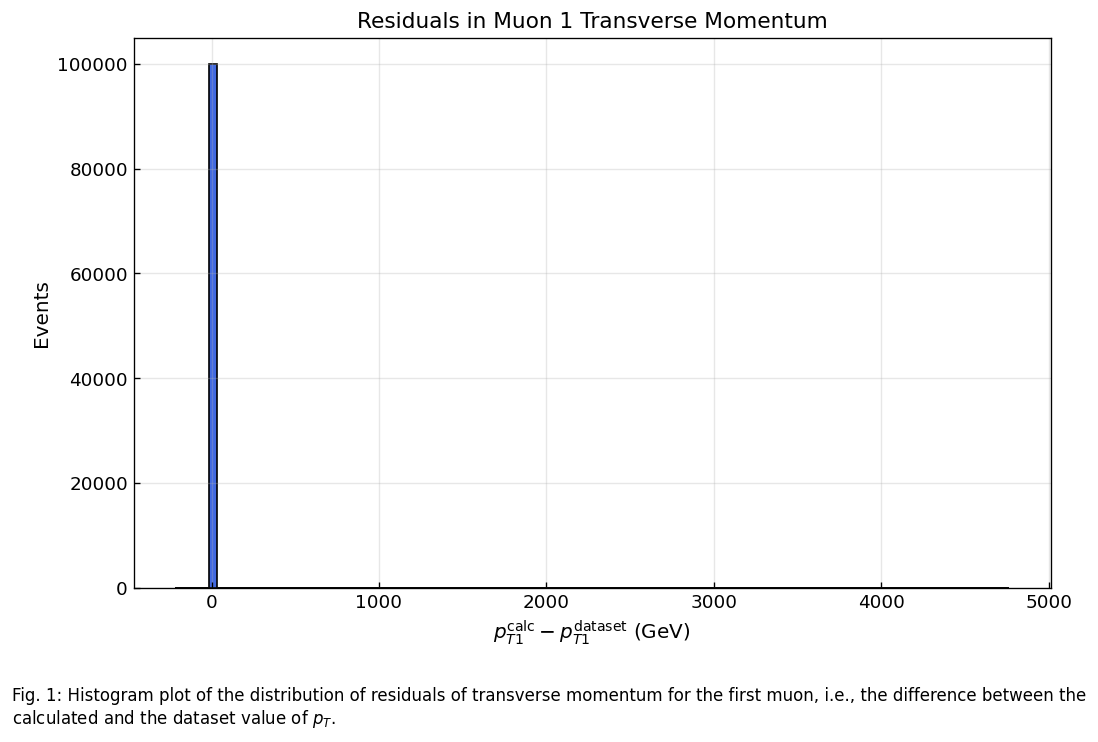

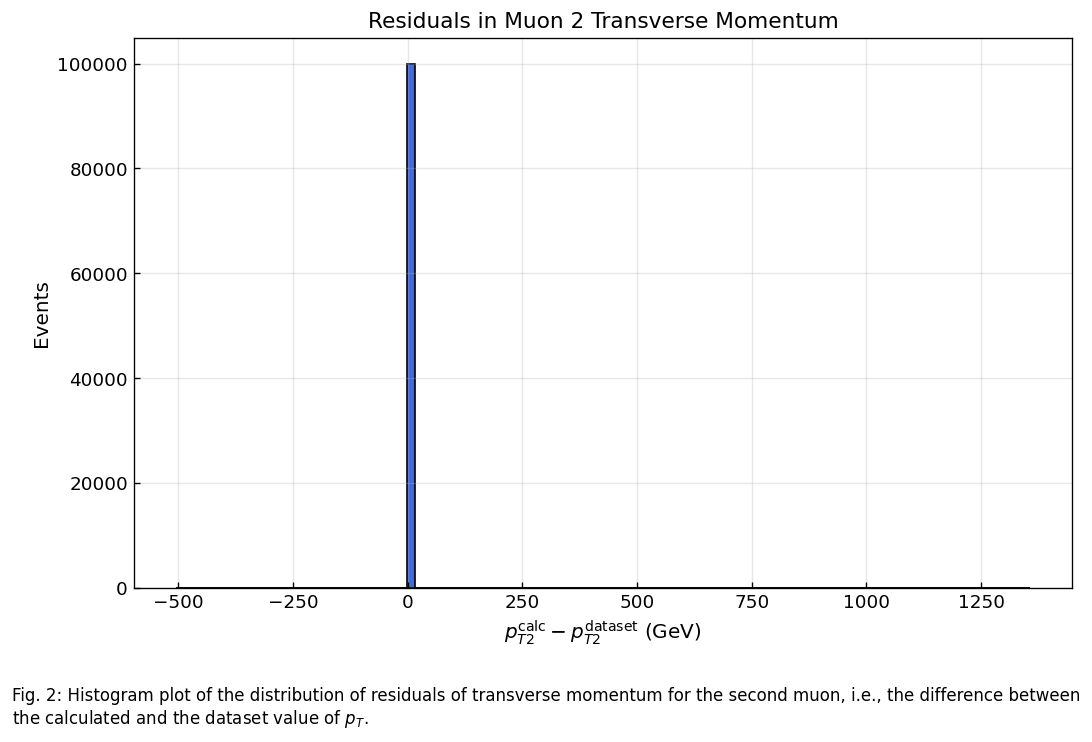

In [12]:
plot_histogram(
    pt1_residual,
    bins=100,
    xlabel=r"$p_{T1}^{\text{calc}}-p_{T1}^{\text{dataset}}$ (GeV)",
    ylabel="Events",
    title="Residuals in Muon 1 Transverse Momentum",
    caption=r"Fig. 1: Histogram plot of the distribution of residuals of transverse momentum for the first muon, i.e., the difference between the calculated and the dataset value of $p_T$."
)

print() # Blank line for spacing

plot_histogram(
    pt2_residual,
    bins=100,
    xlabel=r"$p_{T2}^{\text{calc}}-p_{T2}^{\text{dataset}}$ (GeV)",
    ylabel="Events",
    title="Residuals in Muon 2 Transverse Momentum",
    caption=r"Fig. 2: Histogram plot of the distribution of residuals of transverse momentum for the second muon, i.e., the difference between the calculated and the dataset value of $p_T$."
)

For the overwhelming majority of events, the independently reconstructed transverse momenta agree closely with the supplied values, with residuals around 0. However, a small subset of events exhibits noticeably larger residuals, as depicted in the plots above. These are anomalous events, and are discussed in the next section.

### 5.4. &nbsp; Investigation of Anomalous Events

In [13]:
summary_table, outliers_table = anamolous_events_validation(
    dimuon, 
    pt1_calc, 
    pt1_residual,
    summary_caption="<b>Table 8:</b> Summary of transverse momentum anomalies",
    outlier_table_caption="<b>Table 9:</b> The 10 largest transverse momentum discrepancies, sorted by absolute residuals."
)

display(summary_table)
print("\n")  # Blank lines for spacing
display(outliers_table)

Quantity,Value
Total events,100000
Events with |Residual| > 1 GeV,279
Percentage of dataset,0.279%


Run,Event,E1,px1,py1,pz1,pt1,Calculated pt,Residual,Relative Error (%)
166784,50285782,8684.880,-2872.290,-3846.230,-7237.650,38.277,4800.368,4762.091,12441.06
166784,52198564,53.623,0.342,15.799,51.242,231.431,15.803,-215.628,93.17
167807,1111492546,192.346,3.925,-189.044,35.269,366.499,189.085,-177.414,48.41
166033,522342567,21.239,-13.476,-16.347,-1.502,162.750,21.185,-141.565,86.98
167807,1076313957,74.084,21.744,67.803,-20.451,136.589,71.205,-65.384,47.87
166033,486156267,273.936,-249.704,100.263,51.342,204.698,269.081,64.383,31.45
163340,57817430,16.002,8.027,9.908,9.667,59.161,12.752,-46.410,78.45
165617,85137198,114.600,-20.051,-35.648,-107.053,86.880,40.900,-45.980,52.92
166784,48700562,87.850,81.739,-27.045,17.458,43.576,86.097,42.521,97.58
160957,56980581,124.603,-23.193,68.859,101.226,33.461,72.660,39.199,117.15


Independent reconstruction of the transverse momentum demonstrates excellent agreement with the values supplied in the CMS Open Data for the overwhelming majority of events. Applying a residual threshold of $1 \,\text{GeV}$ identifies only 279 anomalous events, corresponding to approximately $0.28\%$ of the total dataset. Examination of the largest discrepancies shows that these events possess transverse momentum values that are inconsistent with the accompanying Cartesian momentum components. Since the reconstructed values are calculated directly from $(p_x, p_y)$, these discrepancies most likely arise from isolated inconsistencies within the educational dataset rather than from the reconstruction procedure itself. Owing to their small number, these anomalous events are expected to have a negligible impact on the subsequent analysis. This study is not repeated for the second muon candidate for brevity since similar results are expected.

### 5.5. &nbsp; Discussion

The comparison demonstrates that the supplied transverse momentum values are internally consistent for more than $99.7\%$ of the reconstructed dimuon events. The remaining anomalous entries appear to originate from isolated inconsistencies within the educational dataset rather than from the reconstruction procedure implemented in this project. Since the Cartesian momentum components satisfy the expected relativistic relationships, subsequent calculations are performed directly from these components whenever derived observables are required.

## 6. &nbsp; Pseudorapidity Validation

The pseudorapidity of each muon is reconstructed directly from the Cartesian total momentum and $z$-component of momentum, using the standard definition in equation (3). The reconstructed values are then compared with the pseudorapidity $(\eta)$ supplied within the dataset to assess their consistency.

### 6.1 &nbsp; Independent Reconstruction

In [14]:
p1_total = total_momentum_calculation(dimuon["px1"], dimuon["py1"], dimuon["pz1"])
p2_total = total_momentum_calculation(dimuon["px2"], dimuon["py2"], dimuon["pz2"])

eta1_calc = pseudorapidity_calculation(p1_total, dimuon["pz1"])
eta2_calc = pseudorapidity_calculation(p2_total, dimuon["pz2"])

eta1_residual = eta1_calc - dimuon["eta1"]
eta2_residual = eta2_calc - dimuon["eta2"]

### 6.2 &nbsp; Statistical Comparison

In [15]:
eta_comparison_1 = analyse_residuals(eta1_residual)

eta_comparison_2 = analyse_residuals(eta2_residual)

eta_diff_summary = residual_analysis_summary(eta_comparison_1,
                                             eta_comparison_2,
                                             caption="<b>Table 10:</b> Pseudorapidity Validation"
)

eta_diff_summary

,Muon,Mean Residual,Std. Dev.,Max. Abs. Difference,Difference Limits
1,Muon 1,-2.940e-06,0.0025,0.389,"(-0.389, 0.353)"
2,Muon 2,1.223e-06,0.0026,0.356,"(-0.337, 0.356)"


### 6.3 &nbsp; Residual Distribution

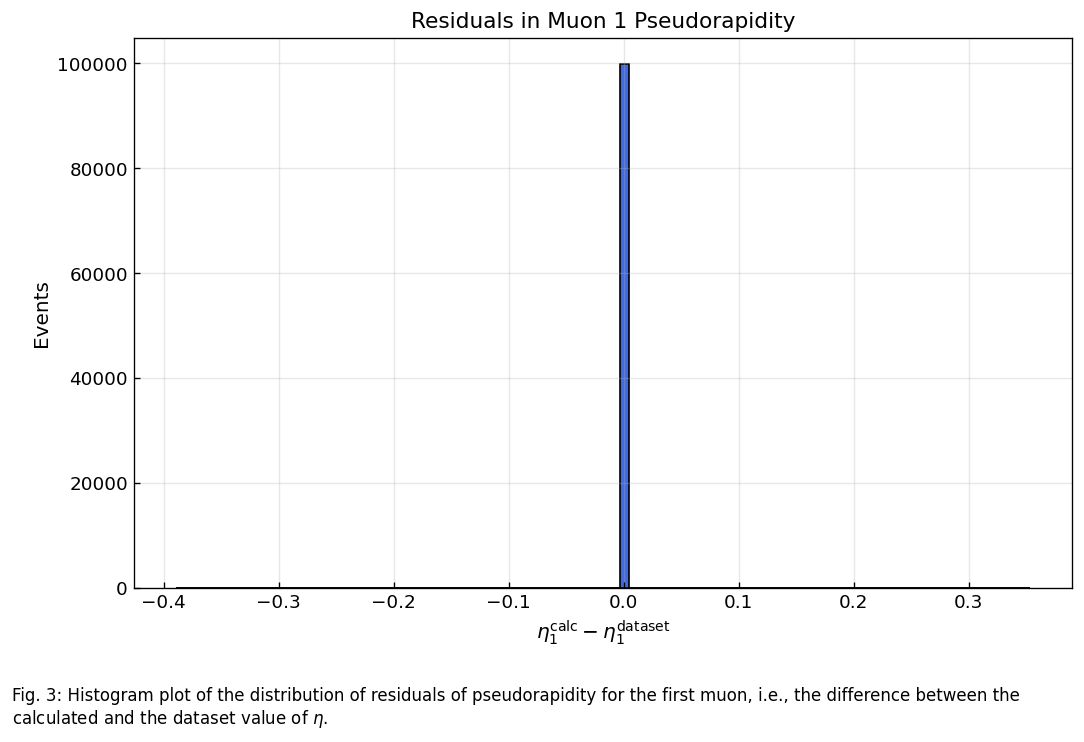

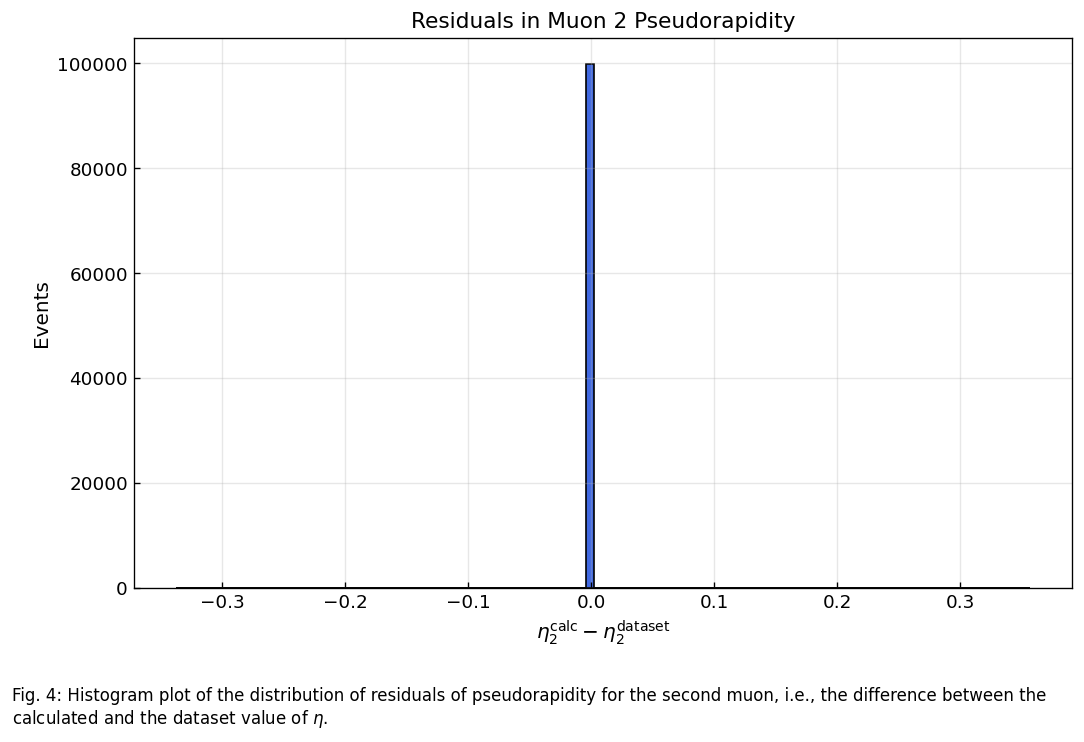

In [16]:
plot_histogram(
    eta1_residual,
    bins=100,
    xlabel=r"$\eta_1^{\text{calc}}-\eta_1^{\text{dataset}}$",
    ylabel="Events",
    title="Residuals in Muon 1 Pseudorapidity",
    caption=r"Fig. 3: Histogram plot of the distribution of residuals of pseudorapidity for the first muon, i.e., the difference between the calculated and the dataset value of $\eta$."
)

print() # Blank line for spacing

plot_histogram(
    eta2_residual,
    bins=100,
    xlabel=r"$\eta_2^{\text{calc}}-\eta_2^{\text{dataset}}$",
    ylabel="Events",
    title="Residuals in Muon 2 Pseudorapidity",
    caption=r"Fig. 4: Histogram plot of the distribution of residuals of pseudorapidity for the second muon, i.e., the difference between the calculated and the dataset value of $\eta$."
)

### 6.4 &nbsp; Discussion

The independently reconstructed pseudorapidity values exhibit excellent agreement with those supplied in the dataset for both reconstructed muons. The residual distributions are sharply centred about zero, with only very small numerical differences arising from floating-point precision and numerical rounding during the reconstruction process. No systematic offsets or anomalous structures are observed, indicating that the stored pseudorapidity values are internally consistent with the Cartesian momentum components. The close agreement confirms that the pseudorapidity has been reconstructed correctly and provides additional confidence in the integrity of the kinematic information contained within the dataset.

## 7. &nbsp; Azimuthal Angle Validation

The azimuthal angle of each muon is reconstructed directly from the Cartesian momentum components $(p_x, \, p_y)$, using the standard definition in equation (4). The reconstructed values are then compared with the azimuthal angle $(\phi)$ supplied within the dataset to assess their consistency.

### 7.1 &nbsp; Independent Reconstruction

In [17]:
phi1_calc = azimuthal_angle_calculation(dimuon["px1"], dimuon["py1"])
phi2_calc = azimuthal_angle_calculation(dimuon["px2"], dimuon["py2"])

### 7.2 &nbsp; Wrapped Residual Calculation

Owing to the periodic nature of the azimuthal angle, direct subtraction may produce apparent residuals close to $2\pi$ whenever one angle lies immediately above $-\pi$ and the other immediately below $+\pi$. These values do not represent genuine physical discrepancies but arise solely from the discontinuity in the angular coordinate. To account for this periodicity, all residuals are wrapped into the interval $(−\pi,\,\pi]$ before statistical analysis.

In [18]:
phi1_residual = azimuthal_angle_residual(phi1_calc, dimuon["phi1"])
phi2_residual = azimuthal_angle_residual(phi2_calc, dimuon["phi2"])

### 7.3 &nbsp; Statistical Comparison

In [19]:
phi_comparison_1 = analyse_residuals(phi1_residual)

phi_comparison_2 = analyse_residuals(phi2_residual)

phi_diff_summary = residual_analysis_summary(phi_comparison_1,
                                             phi_comparison_2,
                                             caption="<b>Table 11:</b> Azimuthal Angle Validation"
)

phi_diff_summary

,Muon,Mean Residual,Std. Dev.,Max. Abs. Difference,Difference Limits
1,Muon 1,3.554e-05,0.0121,2.100,"(-1.571, 2.1)"
2,Muon 2,3.384e-05,0.0084,1.997,"(-0.336, 1.997)"


### 7.4 &nbsp; Residual Distributions

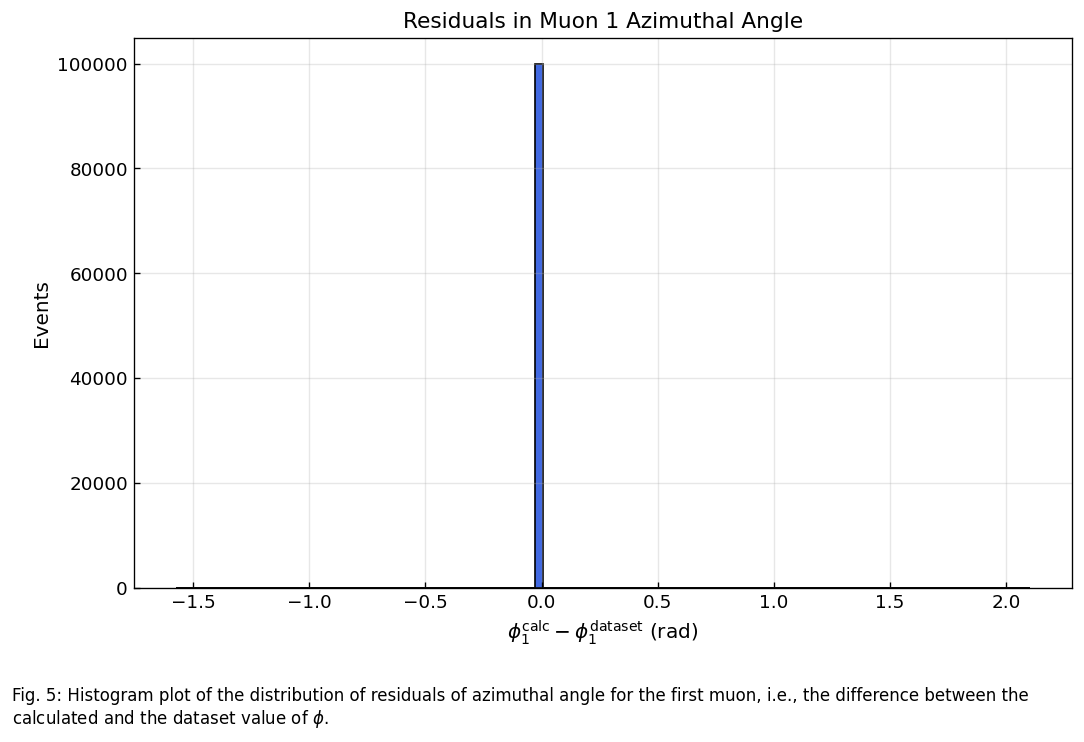

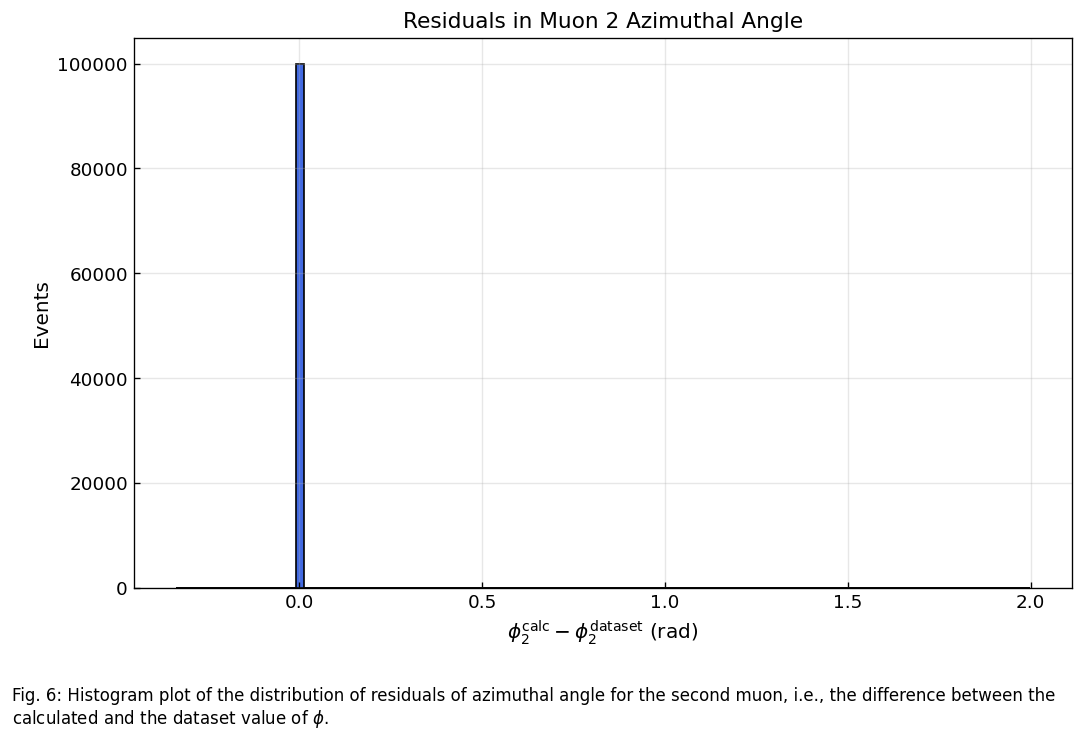

In [20]:
plot_histogram(
    phi1_residual,
    bins=100,
    xlabel=r"$\phi_1^{\text{calc}}-\phi_1^{\text{dataset}}$ (rad)",
    ylabel="Events",
    title="Residuals in Muon 1 Azimuthal Angle",
    caption=r"Fig. 5: Histogram plot of the distribution of residuals of azimuthal angle for the first muon, i.e., the difference between the calculated and the dataset value of $\phi$."
)

print() # Blank line for spacing

plot_histogram(
    phi2_residual,
    bins=100,
    xlabel=r"$\phi_2^{\text{calc}}-\phi_2^{\text{dataset}}$ (rad)",
    ylabel="Events",
    title="Residuals in Muon 2 Azimuthal Angle",
    caption=r"Fig. 6: Histogram plot of the distribution of residuals of azimuthal angle for the second muon, i.e., the difference between the calculated and the dataset value of $\phi$."
)

### 7.5 &nbsp; Discussion

The azimuthal angles reconstructed independently from the Cartesian momentum components exhibit excellent agreement with the values supplied in the dataset. Since the azimuthal coordinate is periodic over the interval $(−\pi,\,\pi]$, residuals were evaluated using an angular wrapping procedure to avoid artificial differences arising at the $\pm \pi$ boundary. Following this correction, the residual distributions for both reconstructed muons are sharply centred about zero, exhibiting only small numerical deviations attributable to floating-point precision and rounding. No systematic offsets or anomalous structures are observed, confirming that the stored azimuthal angles are fully consistent with the corresponding momentum components.


## 8. &nbsp; Conclusion

Independent reconstruction of the principal kinematic observables demonstrates a high degree of internal consistency within the CMS Open Data dimuon sample of 100,000 events. The pseudorapidity and azimuthal angle reproduce the supplied values to excellent numerical precision, while the transverse momentum agrees for more than $99.7\%$ of the analysed events. A small number of anomalous entries exhibiting inconsistent transverse momentum values were identified during the validation procedure, illustrating the importance of verifying supplied observables before undertaking a physics analysis. Having established the reliability of the reconstructed four-momentum information and documented the isolated inconsistencies present within the educational dataset, the analysis can now proceed confidently to event selection and invariant mass reconstruction.